# Heatmap Plot Gallery

Heatmap plots visualise 2D data as a colour-coded matrix with cell values annotated in place. They're the right pick when the eye needs to compare cell-to-cell magnitude across two categorical dimensions while still being able to read exact numbers.

Heatmap plots excel at:
- **Performance grids**: compare a metric across regions x quarters or stores x weeks
- **Migration matrices**: show movement between segments over a period
- **Conversion or footfall patterns**: spot weekday vs weekend or daypart effects
- **Confusion matrices**: read classification results at a glance

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

from openretailscience.plots import heatmap

In [ ]:
# Hand-crafted demo datasets shared across the gallery examples.
# Each dataset is chosen so the chart's headline is true at a glance.

# Regional revenue (in $000s) by quarter. East leads every quarter;
# North grows fastest Q1 -> Q4 (+42% vs East's +33%).
# fmt: off
regional_quarterly = pd.DataFrame(
    {
        "Q1": [120,  95,  85, 135],
        "Q2": [145, 105,  95, 155],
        "Q3": [140, 115,  90, 150],
        "Q4": [170, 125, 100, 180],
    },
    index=["North", "South", "West", "East"],
)
# fmt: on

# Marketing channel weekly conversion rates. Google Ads is the highest
# every week; Social Media the lowest every week.
# fmt: off
channel_conversion = pd.DataFrame(
    {
        "Week 1": [0.024, 0.019, 0.031, 0.020],
        "Week 2": [0.027, 0.020, 0.033, 0.021],
        "Week 3": [0.026, 0.019, 0.030, 0.019],
        "Week 4": [0.029, 0.022, 0.035, 0.023],
    },
    index=["Email", "Social Media", "Google Ads", "Display"],
)
# fmt: on

# Category footfall index across the year. Every category peaks in December;
# Electronics in December (220) is more than 2x its mid-year mean (~91).
# fmt: off
category_monthly_index = pd.DataFrame(
    {
        "Jan": [ 85, 130,  90, 100],
        "Feb": [ 90,  85,  95, 100],
        "Mar": [105,  75, 100, 105],
        "Apr": [115,  80, 120, 110],
        "May": [120,  85, 130, 115],
        "Jun": [130,  95, 138, 120],
        "Jul": [140, 100, 135, 120],
        "Aug": [130,  90, 120, 115],
        "Sep": [115,  85, 110, 115],
        "Oct": [120,  95, 105, 120],
        "Nov": [140, 140, 115, 130],
        "Dec": [170, 220, 142, 145],
    },
    index=["Apparel", "Electronics", "Home Goods", "Grocery"],
)
# fmt: on

# Hourly traffic across days of the week. Saturday at 6pm is the global peak.
# fmt: off
hourly_traffic = pd.DataFrame(
    {
        "Mon": [120, 220, 180, 260, 140],
        "Tue": [110, 210, 175, 250, 135],
        "Wed": [125, 230, 195, 280, 155],
        "Thu": [140, 260, 225, 320, 180],
        "Fri": [180, 340, 290, 410, 240],
        "Sat": [280, 520, 450, 580, 350],
        "Sun": [220, 410, 360, 470, 280],
    },
    index=["9am", "12pm", "3pm", "6pm", "9pm"],
)
# fmt: on

## Basic Heatmap

The simplest call: pass a wide-format DataFrame and the index becomes the y-axis, the columns the x-axis. Cell values are annotated in place, and the colour intensity tracks the underlying number. Pick this shape when the data is already a small matrix you want to compare cell by cell.

---

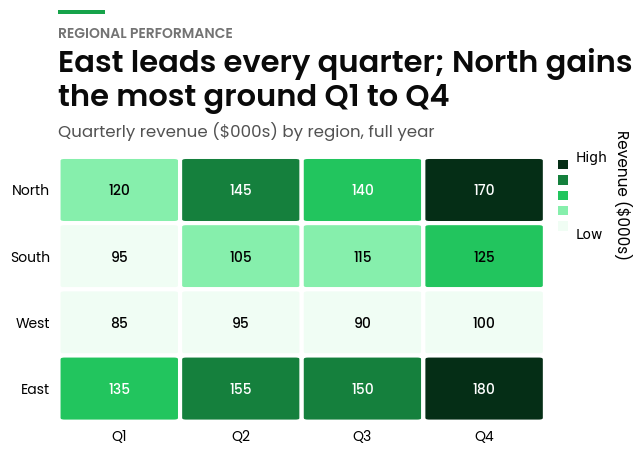

In [ ]:
heatmap.plot(
    regional_quarterly,
    cbar_label="Revenue ($000s)",
    eyebrow="Regional performance",
    title="East leads every quarter; North gains the most ground Q1 to Q4",
    subtitle="Quarterly revenue ($000s) by region, full year",
)
plt.show()

## Percentage Formatting

Pass `cbar_format` to control how cell values are rendered. The format string follows matplotlib's `StrMethodFormatter` syntax (e.g. `"{x:.1%}"` for percentages with one decimal, `"{x:,.0f}"` for thousands separators).

Note: in the default `colormap_style="discrete"` the colorbar is anchored with fixed `"Low"`/`"High"` labels and the format only applies to in-cell text. Switch to `colormap_style="continuous"` (shown here) when you want the format applied to the colorbar tick labels too.

---

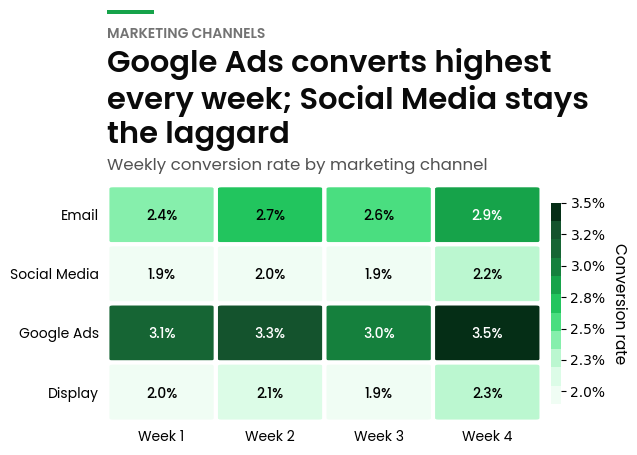

In [ ]:
heatmap.plot(
    channel_conversion,
    cbar_label="Conversion rate",
    cbar_format="{x:.1%}",
    colormap_style="continuous",
    eyebrow="Marketing channels",
    title="Google Ads converts highest every week; Social Media stays the laggard",
    subtitle="Weekly conversion rate by marketing channel",
)
plt.show()

## Continuous Colormap

Use `colormap_style="continuous"` for a smooth gradient when fine-grained magnitude differences matter more than reading exact values per cell. The default `"discrete"` style buckets values into 5 stepped bins for cleaner reading alongside cell annotations.

---

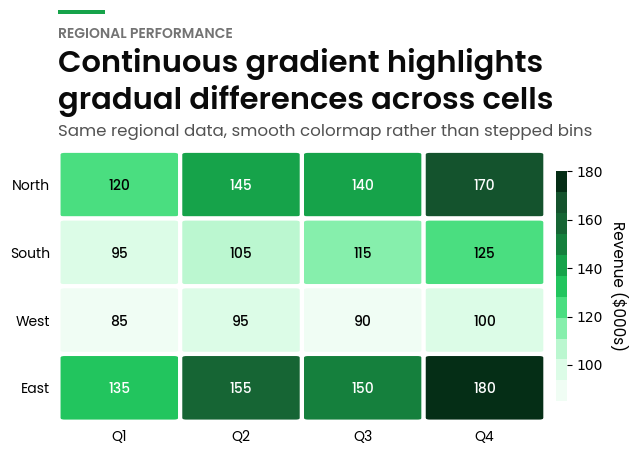

In [ ]:
heatmap.plot(
    regional_quarterly,
    cbar_label="Revenue ($000s)",
    colormap_style="continuous",
    eyebrow="Regional performance",
    title="Continuous gradient highlights gradual differences across cells",
    subtitle="Same regional data, smooth colormap rather than stepped bins",
)
plt.show()

## X-Axis Labels on Top

Set `x_labels_position="top"` to move the column labels above the matrix. Reads more naturally when the columns represent a time progression (months, weeks, periods since acquisition) and the eye should track left-to-right alongside the row labels.

---

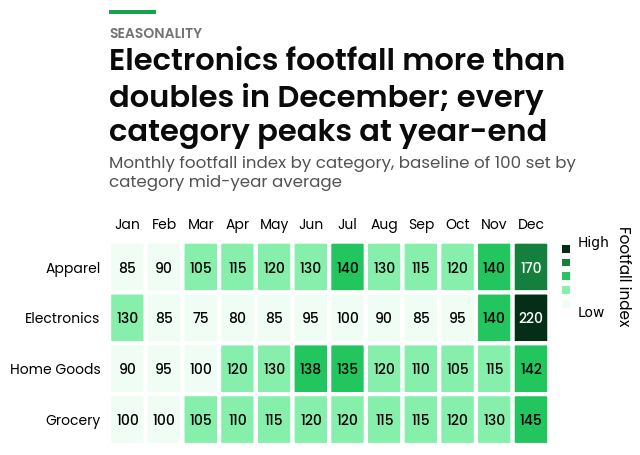

In [ ]:
heatmap.plot(
    category_monthly_index,
    cbar_label="Footfall index",
    x_labels_position="top",
    eyebrow="Seasonality",
    title="Electronics footfall more than doubles in December; every category peaks at year-end",
    subtitle="Monthly footfall index by category, baseline of 100 set by category mid-year average",
)
plt.show()

## Axis Labels and Source Attribution

Add `x_label`/`y_label` when the axis dimensions need explicit naming (rather than relying on the column/index headers alone) and `source_text` for an attribution line beneath the chart on export-ready images. `figsize` lets you size the canvas to the matrix shape rather than relying on the default.

---

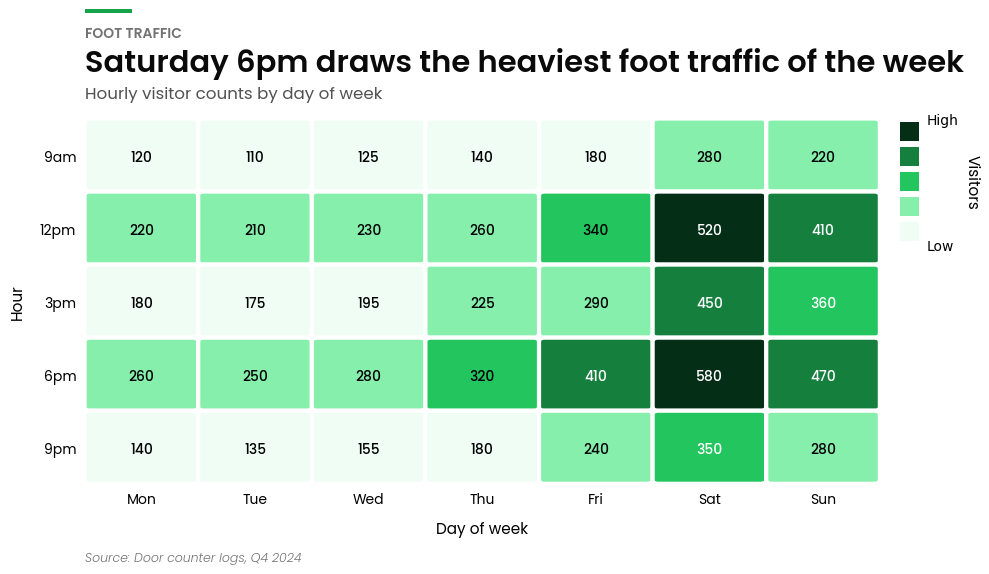

In [ ]:
heatmap.plot(
    hourly_traffic,
    cbar_label="Visitors",
    x_label="Day of week",
    y_label="Hour",
    figsize=(10, 6),
    eyebrow="Foot traffic",
    title="Saturday 6pm draws the heaviest foot traffic of the week",
    subtitle="Hourly visitor counts by day of week",
    source_text="Source: Door counter logs, Q4 2024",
)
plt.show()